# Multidimensional Analysis of Care Trajectories: VICAN Dataset

This notebook presents an exploration of the hyperparameters of the SWoTTeD method on a dataset of cancer care trajectories (1,336 patients, 4 treatment types, follow-up in months).
The goal is to identify a configuration that produces both high-quality reconstruction ($\text{FIT}_X$) and clinically interpretable temporal phenotypes.

## Table of Contents

1. Imports and environment setup
2. Loading and preparing the data
3. Initializing the TCA model and constructing the tensor
4. Joint optimization of $R$, $\omega$, $\tilde{\alpha}$, and $\tilde{\gamma}$ using `Optuna`
5. Clustering based on phenotype intensities

## 1. Imports

### 1.1. Libraries

In [1]:
from pathlib import Path
import sys
import time
import itertools

import random
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import torch
import torch.nn.functional as F

# Loading the TCA package

project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    if (base / "src" / "trajectoryclusteringanalysis").exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Impossible de trouver la racine du projet depuis {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from trajectoryclusteringanalysis.tca import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Package chargé depuis : {src_path}")

Package chargé depuis : c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src


### 1.2. Functions

To simplify the rest of the process, we implement the following functions:
- `run_swotted_trial`: a training function for a given configuration, with early stopping and LR scheduling
- `build_results_df`: aggregates the results into a DataFrame sorted by $\text{FIT}_X$ in descending order
- `compute_normalized_reg_terms`: calculates the true values of $\alpha$ and $\gamma$ from the relative weights $\tilde{\alpha}$ and $\tilde{\gamma}$ and the tensor dimensions
- `plot_training_history`: visualizes the training curve in three panels: total loss and $\text{FIT}_X$ (top panel), the contribution of regularization terms to the total loss (middle panel), and the evolution of $\|P\|_1$ and $S(W)$ over the epochs (bottom panel)
- `phenotype_diversity`: calculates the average cosine diversity among the $R$ phenotypes to verify the absence of redundancy

The `compute_normalized_reg_terms` function implements the following normalization:

$$\alpha = \tilde{\alpha} \cdot \frac{K \cdot T \cdot N}{R \cdot N \cdot \omega} \qquad \gamma = \tilde{\gamma} \cdot \frac{K \cdot T \cdot N}{R \cdot T \cdot K}$$

where $\tilde{\alpha}$ and $\tilde{\gamma}$ are dimensionless relative weights that are comparable across configurations regardless of the value of $R$ or $\omega$.

The `plot_training_history` function plots the following together:
- the total loss and the estimated $\text{FIT}_X$ over the course of the epochs (top panel)
- the contribution of each regularization term to the loss (middle panel)
- the $\|P\|_1$ norm of the phenotypes and the non-succession penalty $S(W)$ (bottom panel)

These curves allow us to assess the effect of the regularization terms.

The `phenotype_diversity` function is defined such that, for each pair of phenotypes $(i, j)$, we calculate:

$$d_{\cos}(\mathcal{P}_i, \mathcal{P}_j) = 1 - \frac{\langle \tilde{p}_i, \tilde{p}_j \rangle}{\|\tilde{p}_i\| \cdot \|\tilde{p}_j\|}$$

where $\tilde{p}_r$ is the flattened and normalized vector of the phenotype $\mathcal{P}_r$. The overall diversity is the average over all pairs $(i < j)$:

$$\text{div}(\mathcal{P}) = \binom{R}{2}^{-1} \sum_{1 \leq i < j \leq R} d_{\cos}(\mathcal{P}_i, \mathcal{P}_j)$$

A value close to $0$ indicates nearly identical phenotypes; a value close to $1$ indicates distinctly different phenotypes (maximum diversity).

In [2]:
def run_swotted_trial(
    timed_event_structure: pd.DataFrame,
    rank: int,
    time_window_length: int,
    reg_ns: float,
    reg_s: float,
    lr: float,
    n_epochs: int,
    metric: str = 'Bernoulli',
    early_stopping: bool = True,
    early_stopping_patience: int = 5,
    early_stopping_min_delta: float = 1e-4,
    fit_metric_every_n_epochs: int = 5,
    fit_metric_eval_max_patients: int = 64,
    num_workers: int = 0,
    lr_schedule_type: str = 'reduce_on_plateau',
    lr_rop_factor: float = 0.5,                 
    lr_rop_patience: int = 10,                    
    lr_rop_min_lr: float = 1e-6,                 
) -> dict:
    print('\n' + '=' * 90)
    print(f"rank={rank}, twl={time_window_length}, reg_ns={reg_ns}, "
          f"reg_s={reg_s}, learning_rate={lr}")
    tca_trial = TCA(
        data=timed_event_structure,
        index_col='ID_PATIENT',
        time_col='Time',
        event_col='Event',
        mode='multidimensional',
    )
    tca_trial.analyzer.transform_time_event_structure_to_tensor()
    tensor_trial = tca_trial.analyzer.get_tensor()
    t0 = time.perf_counter()
    tca_trial.analyzer.fit_swotted_decomposition(
        tensor_trial,
        rank,
        time_window_length,
        reg_ns,
        reg_s,
        metric,
        lr,
        n_epochs,
        fit_metric_every_n_epochs=fit_metric_every_n_epochs,
        fit_metric_eval_max_patients=fit_metric_eval_max_patients,
        restore_best_fit_checkpoint=early_stopping,
        num_workers=num_workers,
        early_stopping_patience=early_stopping_patience if early_stopping else None,
        early_stopping_min_delta=early_stopping_min_delta,
        early_stopping_monitor='fit_metric',
        lr_schedule_type=lr_schedule_type,     
        lr_rop_factor=lr_rop_factor,           
        lr_rop_patience=lr_rop_patience,      
        lr_rop_min_lr=lr_rop_min_lr,          
    )
    elapsed = time.perf_counter() - t0
    hist = getattr(tca_trial.analyzer, 'training_history', {}) or {}
    best_fit       = hist.get('best_fit_metric', None)
    best_fit_epoch = hist.get('best_fit_metric_epoch', None)
    final_fit      = hist.get('final_fit_metric', None)
    epochs_run     = len(hist.get('epoch', []))
    p_l1_values = [v for v in hist.get('p_l1_norm', []) if v is not None]
    ns_values   = [v for v in hist.get('non_succession', []) if v is not None]
    final_p_l1  = p_l1_values[-1] if p_l1_values else None
    final_ns    = ns_values[-1]   if ns_values   else None
    print(f"  best_fit_metric={best_fit:.4f}, final_fit_metric={final_fit:.4f}, "
          f"epochs={epochs_run}, temps={elapsed:.1f}s")
    return {
        'rank':                  rank,
        'time_window_length':    time_window_length,
        'reg_term_ns':           reg_ns,
        'reg_term_s':            reg_s,
        'learning_rate':         lr,
        'epochs_run':            epochs_run,
        'best_fit_metric':       best_fit,
        'best_fit_epoch':        best_fit_epoch,
        'final_fit_metric':      final_fit,
        'final_p_l1_norm':       final_p_l1,       
        'final_non_succession':  final_ns,         
        'elapsed_s':             round(elapsed, 2),
        'tca_trial':             tca_trial,
    }

def build_results_df(results: list) -> pd.DataFrame:
    """Converts a list of results into a DataFrame sorted by best FIT_X in descending order."""
    df = pd.DataFrame(results)
    if not df.empty:
        df = df.sort_values(
            by=['best_fit_metric', 'final_fit_metric'],
            ascending=False,
            na_position='last'
        ).reset_index(drop=True)
    return df

In [3]:
def compute_normalized_reg_terms(K, T, N, R, omega, alpha_rel=0.5, gamma_rel=0.5):
    """
    Calcule alpha et gamma normalisés par les dimensions du tenseur.
    """
    norm_recon  = K * T * N
    norm_sparse = R * N * omega
    norm_ns     = R * T * K

    alpha = float(alpha_rel * (norm_recon / norm_sparse))
    gamma = float(gamma_rel * (norm_recon / norm_ns))
    return alpha, gamma

In [4]:
def plot_training_history(row, title_suffix=""):
    """Displays the training curve (train_loss + FIT_X + regularization) for a configuration.

    Parameters
    ----------
    row: dict or pd.Series
        Row of the results DataFrame containing `tca_trial` and the metadata.
    title_suffix: str
        Optional suffix added to the graph title.
    """
    tca_trial = row['tca_trial']
    history = getattr(tca_trial.analyzer, 'training_history', None)

    if not history or len(history.get('epoch', [])) == 0:
        raise ValueError("No training history available.")

    epochs      = history['epoch']
    train_loss  = history['train_loss_total']
    fit_epochs  = history['fit_metric_points_epoch']
    fit_values  = history['fit_metric_points_value']
    p_l1_values = history.get('p_l1_norm', [])
    ns_values   = history.get('non_succession', [])

    has_reg = any(v is not None for v in p_l1_values) or any(v is not None for v in ns_values)

    if has_reg:
        fig, (ax_top, ax_mid, ax_bot) = plt.subplots(
            3, 1, figsize=(10, 12), sharex=True,
            gridspec_kw={'height_ratios': [3, 2, 2]}
        )
    else:
        fig, ax_top = plt.subplots(figsize=(10, 5))
        ax_mid = None
        ax_bot = None

    # --- Top panel: train_loss + FIT metric ---
    ax_top.plot(epochs, train_loss, color='tab:blue', linewidth=2, label='train_loss_total')
    ax_top.set_ylabel('train_loss_total', color='tab:blue')
    ax_top.tick_params(axis='y', labelcolor='tab:blue')
    ax_top.grid(alpha=0.25)

    ax2 = ax_top.twinx()
    if fit_epochs:
        ax2.plot(fit_epochs, fit_values, color='tab:green',
                 marker='o', linestyle='--', label='FIT metric')
        for i, (x, y) in enumerate(zip(fit_epochs, fit_values)):
            if i % 2 == 0:
                y_offset = 10 if i % 4 == 0 else -15
                ax2.annotate(f"{y:.4f}", (x, y),
                             textcoords='offset points',
                             xytext=(0, y_offset),
                             ha='center', fontsize=9)
        fit_min, fit_max = min(fit_values), max(fit_values)
        fit_span = max(fit_max - fit_min, 1e-6)
        ax2.set_ylim(fit_min - 0.05 * fit_span, fit_max + 0.20 * fit_span)

    ax2.set_ylabel('FIT metric (approx.)', color='tab:green')
    ax2.tick_params(axis='y', labelcolor='tab:green')
    lines  = ax_top.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
    labels = ax_top.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
    ax_top.legend(lines, labels, loc='best')

    if has_reg:
        p_l1_clean = [(e, v) for e, v in zip(epochs, p_l1_values) if v is not None]
        ns_clean   = [(e, v) for e, v in zip(epochs, ns_values)   if v is not None]

        alpha_val = float(row.get('reg_term_s', 1.0))
        gamma_val = float(row.get('reg_term_ns', 1.0))

        loss_clean  = [v for v in train_loss if v is not None]
        epochs_loss = [e for e, v in zip(epochs, train_loss) if v is not None]

        # --- Middle panel: Contributions as a percentage of total loss ---
        if ax_mid is not None:
            if p_l1_clean:
                ep, vp = zip(*p_l1_clean)
                loss_interp_p = np.interp(ep, epochs_loss, loss_clean)
                pct_p = [100 * alpha_val * v / l if l > 0 else 0
                         for v, l in zip(vp, loss_interp_p)]
                ax_mid.plot(ep, pct_p, color='darkorange', linewidth=1.5,
                            label=r'\alpha \cdot \|P\|_1$ / loss (%)')

            if ns_clean:
                en, vn = zip(*ns_clean)
                loss_interp_ns = np.interp(en, epochs_loss, loss_clean)
                pct_ns = [100 * gamma_val * v / l if l > 0 else 0
                          for v, l in zip(vn, loss_interp_ns)]
                ax_mid.plot(en, pct_ns, color='darkgreen', linewidth=1.5,
                            linestyle='--', label=r'\gamma \cdot S(W)$ / loss (%)')

            ax_mid.set_ylabel('Contribution à la loss (%)')
            ax_mid.tick_params(axis='y')
            ax_mid.grid(alpha=0.25)
            ax_mid.legend(loc='best')

            # --- Bottom panel: raw values ||P||_1 and S(W) ---
            if ax_bot is not None:
                if p_l1_clean:
                    ep, vp = zip(*p_l1_clean)
                    ax_bot.plot(ep, vp, color='darkorange', linewidth=1.5,
                                label=r'\|P\|_1$ (sparsité)')

                if ns_clean:
                    en, vn = zip(*ns_clean)
                    ax_ns = ax_bot.twinx()
                    ax_ns.plot(en, vn, color='darkgreen', linewidth=1.5,
                               linestyle='--', label=r'$S(W)$ (non-succession)')
                    ax_ns.set_ylabel(r'$S(W)$', color='darkgreen')
                    ax_ns.tick_params(axis='y', labelcolor='darkgreen')
                    lines2  = ax_bot.get_legend_handles_labels()[0] + ax_ns.get_legend_handles_labels()[0]
                    labels2 = ax_bot.get_legend_handles_labels()[1] + ax_ns.get_legend_handles_labels()[1]
                    ax_bot.legend(lines2, labels2, loc='best')
                else:
                    ax_bot.legend(loc='best')

                ax_bot.set_ylabel(r'$\|P\|_1$', color='darkorange')
                ax_bot.tick_params(axis='y', labelcolor='darkorange')
                ax_bot.grid(alpha=0.25)
                ax_bot.set_xlabel('Epoch')
    else:
        ax_top.set_xlabel('Epoch')

    cfg = (f"R={row['rank']}, ω={row['time_window_length']}, "
           f"α={row['reg_term_s']}, γ={row['reg_term_ns']}, "
           f"lr={row['learning_rate']}")
    fig.suptitle(f"Training — {cfg}{(' — ' + title_suffix) if title_suffix else ''}")
    plt.tight_layout()
    plt.show()


In [5]:
def phenotype_diversity(Ph_tensor: torch.Tensor, eps: float = 1e-12):
    """Calculates the average cosine diversity among R phenotypes.

    Parameters
    ----------
    Ph_tensor: torch.Tensor
        Tensor of shape (R, N, w).
    eps: float
        Value for numerical stability during normalization.

    Returns
    -------
    div_value: float
        Average 1-cosine diversity, in [0, 1].
    pairwise_div: torch.Tensor
        Pairwise diversity matrix of shape (R, R), with zeros on the diagonal.
    """
    if not isinstance(Ph_tensor, torch.Tensor):
        Ph_tensor = torch.as_tensor(Ph_tensor, dtype=torch.float32)

    if Ph_tensor.ndim != 3:
        raise ValueError(f"Expected format (R, N, w), received {tuple(Ph_tensor.shape)}")

    R = Ph_tensor.shape[0]
    if R < 2:
        return 0.0, torch.zeros((R, R), dtype=Ph_tensor.dtype, device=Ph_tensor.device)

    # Flattening (N, w) → vector in R^(N*w), then L2 normalization
    P = Ph_tensor.reshape(R, -1).float()
    P = F.normalize(P, p=2, dim=1, eps=eps)

    # Cosine similarity matrix
    cos_sim = P @ P.T

    # Diversity matrice : 1 - cos(P_i, P_j)
    pairwise_div = 1.0 - cos_sim
    pairwise_div.fill_diagonal_(0.0)

    # Average across pairs (i < j)
    upper_idx = torch.triu_indices(R, R, offset=1, device=pairwise_div.device)
    div_value = pairwise_div[upper_idx[0], upper_idx[1]].mean().item()

    return div_value, pairwise_div


def print_diversity(row):
    """Displays the phenotypic diversity and the pairwise matrix for a configuration."""
    tca_trial = row['tca_trial']
    Ph_tensor = tca_trial.analyzer.model.Ph.detach()
    div_value, pairwise_div = phenotype_diversity(Ph_tensor)

    print(f"Phenotypic diversity (mean 1 - cosine) : {div_value:.6f}\n")

    R = pairwise_div.shape[0]
    col_names = [f"Phenotype_{i+1}" for i in range(R)]
    df = pd.DataFrame(
        pairwise_div.cpu().numpy(),
        index=col_names,
        columns=col_names,
    )
    display(df)

## 2. Data Loading and Preparation

### 2.1. Loading

The dataset is in long format: each row corresponds to an event for a patient at a given time.
The four types of events are: surgery, IV chemotherapy, oral chemotherapy, and radiation therapy.

In [6]:
df = pd.read_csv(project_root / "data" / "multidimensional_data.csv")
print(f"Dimensions : {df.shape[0]} lines, {df.shape[1]} columns")
print(f"Columns   : {list(df.columns)}")
df.head()

Dimensions : 20435 lines, 3 columns
Columns   : ['PATIENT_ID', 'EVENT', 'TIME']


,PATIENT_ID,EVENT,TIME
0,1,Chirurgie,0
1,1,Chimiothérapie IV,1
2,1,Chimiothérapie IV,1
3,1,Chimiothérapie IV,2
4,1,Chimiothérapie IV,3


### 2.2. Event Encoding

Event labels are encoded as integers to be passed to the TCA model. We retain `name_events` for visualizations.

In [7]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
timed_event_structure = df.copy()
timed_event_structure['Event'] = label_encoder.fit_transform(timed_event_structure['EVENT'])
timed_event_structure.drop(columns=['EVENT'], inplace=True)
timed_event_structure.columns = ['ID_PATIENT', 'Time', 'Event']

# Traduction FR -> EN
translation = {
    "Chirurgie"       : "Surgery",
    "Chimiothérapie per os"  : "Oral chemotherapy",
    "Radiothérapie"   : "Radiotherapy",
    "Chimiothérapie IV"   : "IV Chemotherapy"
}

name_events = [translation.get(e, e) for e in label_encoder.classes_]

print(f"Événements encodés : {name_events}")
timed_event_structure.head()

Événements encodés : ['IV Chemotherapy', 'Oral chemotherapy', 'Surgery', 'Radiotherapy']


,ID_PATIENT,Time,Event
0,1,0,2
1,1,1,0
2,1,1,0
3,1,2,0
4,1,3,0


### 2.3. Descriptive Statistics

In [8]:
n_patients = timed_event_structure['ID_PATIENT'].unique()
n_events   = timed_event_structure['Event'].unique()
max_duration = timed_event_structure['Time'].max()
avg_duration = timed_event_structure.groupby('ID_PATIENT')['Time'].max().mean ()

print(f"Number of patients         : {len(n_patients)}")
print(f"Number of event types     : {len(n_events)}")
print(f"Maximum duration : {max_duration} months")
print(f"Average duration : {avg_duration:.1f} months")

Number of patients         : 1336
Number of event types     : 4
Maximum duration : 23 months
Average duration : 7.6 months


In [9]:
# Patients who have received all 4 types of treatment at least once
all_events = set(timed_event_structure['Event'].unique())
patients_complets = (
    timed_event_structure
    .groupby('ID_PATIENT')
    .filter(lambda g: set(g['Event']) == all_events)
    ['ID_PATIENT'].unique()
)
print(f"Number of patients who received {len(all_events)} differents treayments : {len(patients_complets)} at least once")

Number of patients who received 4 differents treayments : 50 at least once


In [10]:
from itertools import combinations

# 1. Patients per event
patients_per_event = {
    event: timed_event_structure[timed_event_structure['Event'] == event]['ID_PATIENT'].nunique()
    for event in [0, 1, 2, 3]
}

# 2. Simultaneous treatments
concomitants = (
    timed_event_structure
    .groupby(['ID_PATIENT', 'Time'])['Event']
    .count()
    .reset_index()
    .rename(columns={'Event': 'n_events'})
)

simultaneous = {
    n: {
        'patients':    concomitants[concomitants['n_events'] >= n]['ID_PATIENT'].nunique(),
        'occurrences': (concomitants['n_events'] >= n).sum(),
    }
    for n in [2, 3, 4]
}

# 3. Co-occurring pairs
def get_pairs(group):
    events = group['Event'].tolist()
    return list(combinations(sorted(events), 2))

pairs_long = (
    timed_event_structure
    .groupby(['ID_PATIENT', 'Time'])
    .apply(get_pairs)
    .explode()
    .dropna()
    .reset_index()
    .rename(columns={0: 'pair'})
)

pair_occurrences = pairs_long['pair'].value_counts()
pair_patients    = pairs_long.groupby('pair')['ID_PATIENT'].nunique()

pairs_df = pd.DataFrame({
    'occurrences': pair_occurrences,
    'patients':    pair_patients,
}).sort_values('occurrences', ascending=False)

# 4. Total occurrences per event
occurrences_per_event = timed_event_structure['Event'].value_counts().sort_index()

# Summary display
print("=" * 50)
print("PATIENTS PER EVENT")
for ev, n in patients_per_event.items():
    print(f"  Event {ev}: {n:>5} patients")

print("\nSIMULTANEOUS TREATMENTS")
for n, stats in simultaneous.items():
    print(f"  >= {n} at once: {stats['patients']:>5} patients  |  {stats['occurrences']:>5} occurrences")

print("\nCO-OCCURRING PAIRS")
print(f"  {'Pair':<12} {'Patients':>10} {'Occurrences':>13}")
print("  " + "-" * 36)
for pair, row in pairs_df.iterrows():
    print(f"  {str(pair):<12} {int(row['patients']):>10} {int(row['occurrences']):>13}")

print("\nTOTAL OCCURRENCES PER EVENT")
for ev, n in occurrences_per_event.items():
    print(f"  Event {ev}: {n:>6} occurrences")
print("=" * 50)

PATIENTS PER EVENT
  Event 0:   880 patients
  Event 1:   327 patients
  Event 2:   734 patients
  Event 3:   329 patients

SIMULTANEOUS TREATMENTS
  >= 2 at once:  1033 patients  |   5747 occurrences
  >= 3 at once:   820 patients  |   1900 occurrences
  >= 4 at once:   444 patients  |   1082 occurrences

CO-OCCURRING PAIRS
  Pair           Patients   Occurrences
  ------------------------------------
  (3, 3)              318         25383
  (0, 0)              844         10694
  (0, 3)               97          2907
  (1, 3)              154          1391
  (0, 1)              106           610
  (1, 1)              129           227
  (2, 2)               64            68
  (2, 3)               10            46
  (0, 2)               33            39
  (1, 2)                8            10

TOTAL OCCURRENCES PER EVENT
  Event 0:  14334 occurrences
  Event 1:    944 occurrences
  Event 2:    835 occurrences
  Event 3:   4322 occurrences


## 3. Initializing the TCA model and the tensor

### 3.1. Initializing the TCA Model

We instantiate the TCA model in multidimensional mode by passing it the dataset.

In [11]:
tca = TCA(
    data=timed_event_structure,
    index_col='ID_PATIENT',
    alphabet=name_events,
    states=name_events,
    time_col='Time',
    event_col='Event',
    mode='multidimensional',
)

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (20435, 3)
state coding:
             alphabet              label  label encoded
0    IV Chemotherapy    IV Chemotherapy              1
1  Oral chemotherapy  Oral chemotherapy              2
2            Surgery            Surgery              3
3       Radiotherapy       Radiotherapy              4


### 3.2. Tensor Construction

The data are converted into a tensor of dimension $K \times n \times T_k$ (patients × events × time).

In [12]:
tca.analyzer.transform_time_event_structure_to_tensor()
tensor = tca.analyzer.get_tensor()

shape = tca.analyzer.get_tensor_shape()
print(f"Number of patients  : {shape[0]}")
print(f"Number of events : {shape[1]}")
print(f"Maximum duration      : {shape[2]} months")

Number of patients  : 1336
Number of events : 4
Maximum duration      : 24 months


### 3.3. Visualizing an Individual Trajectory

We visualize the matrix for a patient who received all four types of treatment to verify that the tensor was constructed correctly.

Patient used for visualization : 8


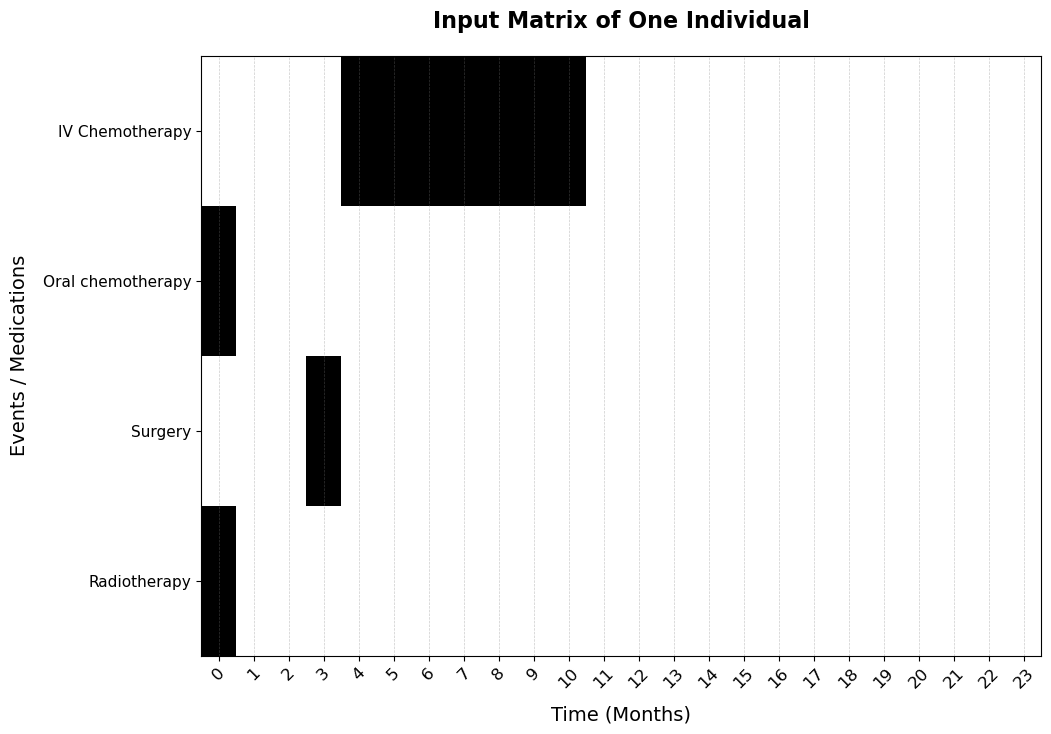

In [13]:
patient_index = int(patients_complets[0])
print(f"Patient used for visualization : {patient_index}")
plot_input_matrix(tensor, id=patient_index, labels=tca.label_to_encoded, time_unit='Months')

## 4. Exploration des paramètres

## 4. Exploring SWoTTeD Hyperparameters

The values of $\alpha$ and $\gamma$ are calculated from the relative weights $\tilde{\alpha}$ and $\tilde{\gamma}$ using `compute_normalized_reg_terms`. Before running the simulations, we display the corresponding actual values to ensure they are within a reasonable order of magnitude.

We randomly sample 10 configurations from the hyperparameter space defined by $R \in \{2, 3, 4, 5\}$, $\omega \in \{2, 3, 4, 5\}$, $\tilde{\alpha} \in \{10^{-5}, 10^{-3}\}$, and $\tilde{\gamma} \in \{0.5, 10\}$. 

For each configuration, we record $\text{FIT}_X$ and $\text{div}(\mathcal{P})$. The best model state is saved for each run via the checkpoint mechanism, and all results are aggregated into a DataFrame sorted by descending $\text{FIT}_X$, then by descending $\text{div}(\mathcal{P})$.

In [14]:
K = tca.analyzer.K
T = tca.analyzer.T
N = tca.analyzer.N

for R in [2, 3, 4, 5]:
    for omega in [2, 3, 4, 5]:
        factor_alpha = (K * T) / (R * omega)
        factor_gamma = N / R
        print(f"R={R}, ω={omega} → factor_α={factor_alpha:.0f}, factor_γ={factor_gamma:.2f}")

R=2, ω=2 → factor_α=8016, factor_γ=2.00
R=2, ω=3 → factor_α=5344, factor_γ=2.00
R=2, ω=4 → factor_α=4008, factor_γ=2.00
R=2, ω=5 → factor_α=3206, factor_γ=2.00
R=3, ω=2 → factor_α=5344, factor_γ=1.33
R=3, ω=3 → factor_α=3563, factor_γ=1.33
R=3, ω=4 → factor_α=2672, factor_γ=1.33
R=3, ω=5 → factor_α=2138, factor_γ=1.33
R=4, ω=2 → factor_α=4008, factor_γ=1.00
R=4, ω=3 → factor_α=2672, factor_γ=1.00
R=4, ω=4 → factor_α=2004, factor_γ=1.00
R=4, ω=5 → factor_α=1603, factor_γ=1.00
R=5, ω=2 → factor_α=3206, factor_γ=0.80
R=5, ω=3 → factor_α=2138, factor_γ=0.80
R=5, ω=4 → factor_α=1603, factor_γ=0.80
R=5, ω=5 → factor_α=1283, factor_γ=0.80


In [15]:
for R in [2, 3, 4, 5]:
    for omega in [2, 3, 4, 5]:
        for alpha_rel, gamma_rel in [(1e-5, 0.), (1e-4, 5), (1e-3, 10)]:
            a, g = compute_normalized_reg_terms(K, T, N, R=R, omega=omega,
                                                alpha_rel=alpha_rel, gamma_rel=gamma_rel)
            print(f"R={R}, ω={omega}, α_rel={alpha_rel} → α={a:.4f}, γ={g:.4f}")

R=2, ω=2, α_rel=1e-05 → α=0.0802, γ=0.0000
R=2, ω=2, α_rel=0.0001 → α=0.8016, γ=10.0000
R=2, ω=2, α_rel=0.001 → α=8.0160, γ=20.0000
R=2, ω=3, α_rel=1e-05 → α=0.0534, γ=0.0000
R=2, ω=3, α_rel=0.0001 → α=0.5344, γ=10.0000
R=2, ω=3, α_rel=0.001 → α=5.3440, γ=20.0000
R=2, ω=4, α_rel=1e-05 → α=0.0401, γ=0.0000
R=2, ω=4, α_rel=0.0001 → α=0.4008, γ=10.0000
R=2, ω=4, α_rel=0.001 → α=4.0080, γ=20.0000
R=2, ω=5, α_rel=1e-05 → α=0.0321, γ=0.0000
R=2, ω=5, α_rel=0.0001 → α=0.3206, γ=10.0000
R=2, ω=5, α_rel=0.001 → α=3.2064, γ=20.0000
R=3, ω=2, α_rel=1e-05 → α=0.0534, γ=0.0000
R=3, ω=2, α_rel=0.0001 → α=0.5344, γ=6.6667
R=3, ω=2, α_rel=0.001 → α=5.3440, γ=13.3333
R=3, ω=3, α_rel=1e-05 → α=0.0356, γ=0.0000
R=3, ω=3, α_rel=0.0001 → α=0.3563, γ=6.6667
R=3, ω=3, α_rel=0.001 → α=3.5627, γ=13.3333
R=3, ω=4, α_rel=1e-05 → α=0.0267, γ=0.0000
R=3, ω=4, α_rel=0.0001 → α=0.2672, γ=6.6667
R=3, ω=4, α_rel=0.001 → α=2.6720, γ=13.3333
R=3, ω=5, α_rel=1e-05 → α=0.0214, γ=0.0000
R=3, ω=5, α_rel=0.0001 → α=0.2138, γ

In [ ]:
random.seed(42)
np.random.seed(42)

sampled_configs = [
    (
        random.randint(2, 4),
        random.randint(2, 5),
        float(np.exp(random.uniform(np.log(1e-5), np.log(1e-3)))),
        float(np.exp(random.uniform(np.log(0.1),  np.log(10.0)))),
    )
    for _ in range(10)
]

all_results = []

for rank, twl, alpha_rel, gamma_rel in sampled_configs:
    alpha, gamma = compute_normalized_reg_terms(
        K=K, T=T, N=N,
        R=rank, omega=twl,
        alpha_rel=alpha_rel,
        gamma_rel=gamma_rel,
    )

    t0 = time.time()
    print(f"\nRunning trial with rank={rank}, twl={twl}, alpha_rel={alpha_rel:.5f}, gamma_rel={gamma_rel:.5f} "
          f"→ alpha={alpha:.5f}, gamma={gamma:.5f} ...")
    result = run_swotted_trial(
        timed_event_structure,
        rank=rank, time_window_length=twl,
        reg_ns=gamma, reg_s=alpha,
        lr=1e-2, n_epochs=500,
        early_stopping=True,
        fit_metric_every_n_epochs=10,
        early_stopping_patience=5,
    )
    result['elapsed_sec'] = round(time.time() - t0, 2)

    result['rank']      = rank
    result['twl']       = twl
    result['alpha_rel'] = alpha_rel
    result['gamma_rel'] = gamma_rel
    result['alpha']     = alpha
    result['gamma']     = gamma

    fit_metric = result.get('best_fit_metric')

    if fit_metric is None:
        result['fit_metric'] = None
        result['div_cos']    = None
    else:
        try:
            Ph_tensor = result['tca_trial'].analyzer.model.Ph.detach()
            div_cos, _ = phenotype_diversity(Ph_tensor)
        except Exception:
            div_cos = None
        result['fit_metric'] = fit_metric
        result['div_cos']    = div_cos

    all_results.append(result)

results_df = (pd.DataFrame(all_results)
                .sort_values(by=['fit_metric', 'div_cos'], ascending=[False, False])
                .reset_index(drop=True))

display(results_df.drop(columns='tca_trial'))

INFO:root:TCA object initialized successfully
INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.



Running trial with rank=2, twl=2, alpha_rel=0.00030, gamma_rel=0.30888 → alpha=2.43814, gamma=0.61775 ...

rank=2, twl=2, reg_ns=0.6177513501598542, reg_s=2.438140384554348, learning_rate=0.01
Dataset :
data shape:  (20435, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelChec


 -> Starting training


c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=3` in the `DataLoader` to improve performance.


...

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | model        | SlidingWindow | 0      | train | 0    
  | other params | n/a           | 40     | n/a   | n/a  
--------------------------------------


 -> Starting training


Training: |          | 0/? [00:00<?, ?it/s]

Epoch 1/500 : - train_loss_Ph: 18.989214 - train_loss_W: 241.160156 - train_loss_total: 260.149370 - duration: 4.86s - FIT metric: 0.1182 - ||P||_1: 1.0628 - S(X): 0.1559
    early stopping: Metric fit_metric initialized at 0.118.
    checkpoint: New best FIT metric = 0.1182 at epoch 1.
    lr_scheduler: learning rate = 1.00e-02
Epoch 2/500 : - train_loss_Ph: 14.181110 - train_loss_W: 228.580139 - train_loss_total: 242.761250 - duration: 5.57s - ||P||_1: 0.5909 - S(X): 0.1935
    lr_scheduler: learning rate = 1.00e-02
Epoch 3/500 : - train_loss_Ph: 14.285494 - train_loss_W: 220.845261 - train_loss_total: 235.130754 - duration: 4.91s - ||P||_1: 0.6096 - S(X): 0.1989
    lr_scheduler: learning rate = 1.00e-02
Epoch 4/500 : - train_loss_Ph: 14.281368 - train_loss_W: 213.122559 - train_loss_total: 227.403927 - duration: 4.73s - ||P||_1: 0.6229 - S(X): 0.1790
    lr_scheduler: learning rate = 1.00e-02
Epoch 5/500 : - train_loss_Ph: 14.275052 - train_loss_W: 205.488800 - train_loss_total: 21

,rank,time_window_length,reg_term_ns,reg_term_s,learning_rate,epochs_run,best_fit_metric,best_fit_epoch,final_fit_metric,final_p_l1_norm,final_non_succession,elapsed_s,elapsed_sec,twl,alpha_rel,gamma_rel,alpha,gamma,fit_metric,div_cos
0,5,3,0.288052,0.169178,0.01,140,0.542899,40,0.530003,30.237091,45.634655,8470.48,8471.72,3,0.000079,0.360065,0.169178,0.288052,0.542899,0.742931
1,2,2,0.617751,2.438140,0.01,160,0.537906,60,0.537882,9.698366,30.975416,9559.39,9560.89,2,0.000304,0.308876,2.438140,0.617751,0.537906,0.999438
2,2,3,0.958365,1.330899,0.01,170,0.507473,70,0.498814,14.918664,13.631925,10476.62,10478.04,3,0.000249,0.479183,1.330899,0.958365,0.507473,0.998858
3,3,3,0.628243,2.925508,0.01,160,0.499151,60,0.488932,9.527466,35.962479,10661.58,10663.05,3,0.000821,0.471182,2.925508,0.628243,0.499151,0.800151
4,4,2,1.181561,1.154493,0.01,170,0.449562,70,0.443800,14.853937,8.111734,10575.89,10577.25,2,0.000288,1.181561,1.154493,1.181561,0.449562,0.889478
5,3,2,3.605603,0.708527,0.01,190,0.441332,90,0.439505,15.858497,0.846555,10554.01,10555.29,2,0.000133,2.704203,0.708527,3.605603,0.441332,0.970537
6,5,2,3.646694,0.407473,0.01,190,0.439487,90,0.436410,18.138536,1.324723,10328.44,10329.77,2,0.000127,4.558367,0.407473,3.646694,0.439487,0.766095
7,2,5,0.307908,0.037118,0.01,150,0.395051,50,0.386698,29.020660,21.388195,8601.47,8602.97,5,0.000012,0.153954,0.037118,0.307908,0.395051,0.996569
8,2,5,9.908747,0.050055,0.01,210,0.385489,110,0.382508,36.040913,0.114966,12490.44,12491.85,5,0.000016,4.954373,0.050055,9.908747,0.385489,0.960085
9,3,2,8.115175,1.205773,0.01,240,0.359207,140,0.362430,10.102719,0.145389,12788.42,12789.75,2,0.000226,6.086381,1.205773,8.115175,0.359207,0.692316


=== Meilleure configuration ===
rank      : 3
twl       : 2
alpha_rel : 1.33e-04
gamma_rel : 2.70e+00
alpha     : 7.09e-01
gamma     : 3.61e+00
FIT_X     : 0.4413
div_cos  : 0.9705


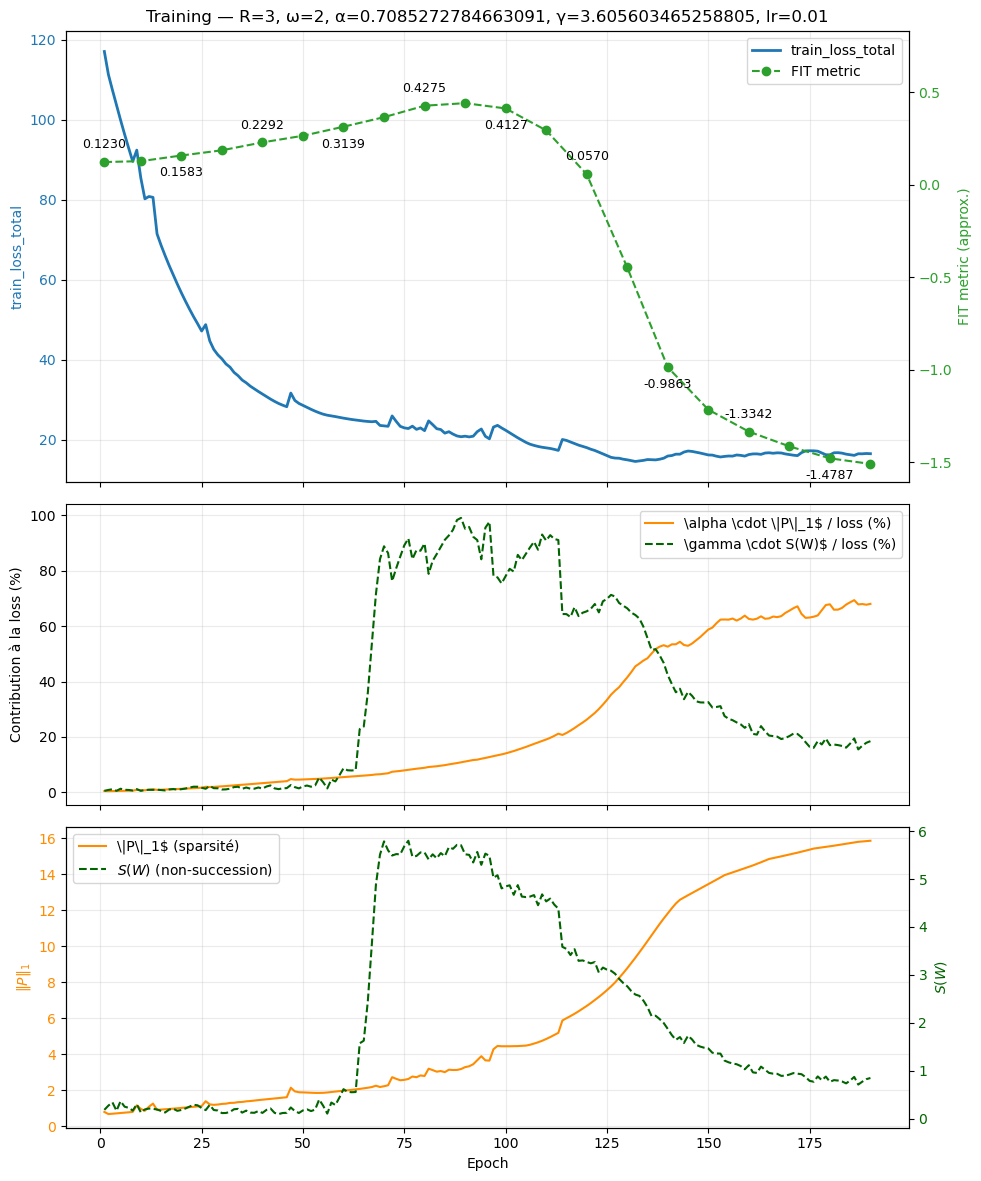

Decomposed into 1336 pathways with rank 3 and time window length 2
Success rate for the entire dataset: 0.4393


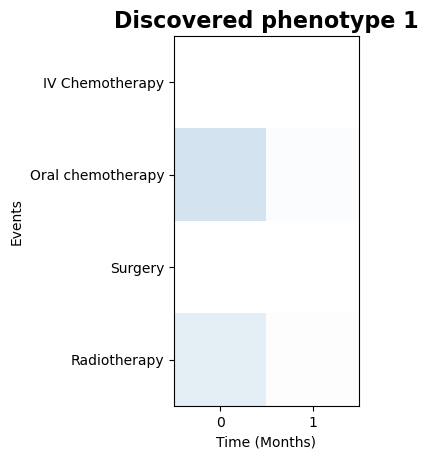

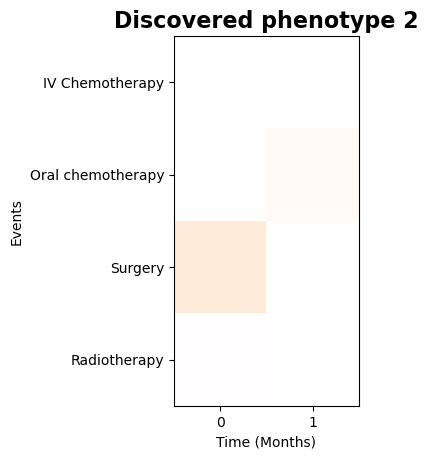

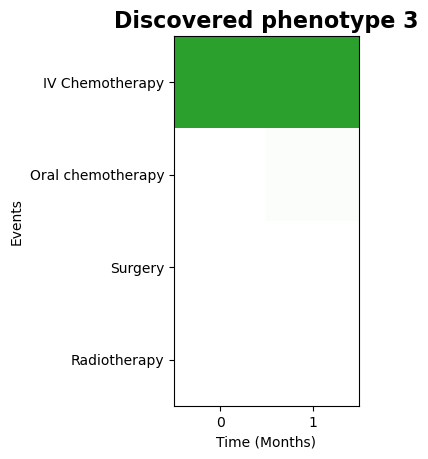

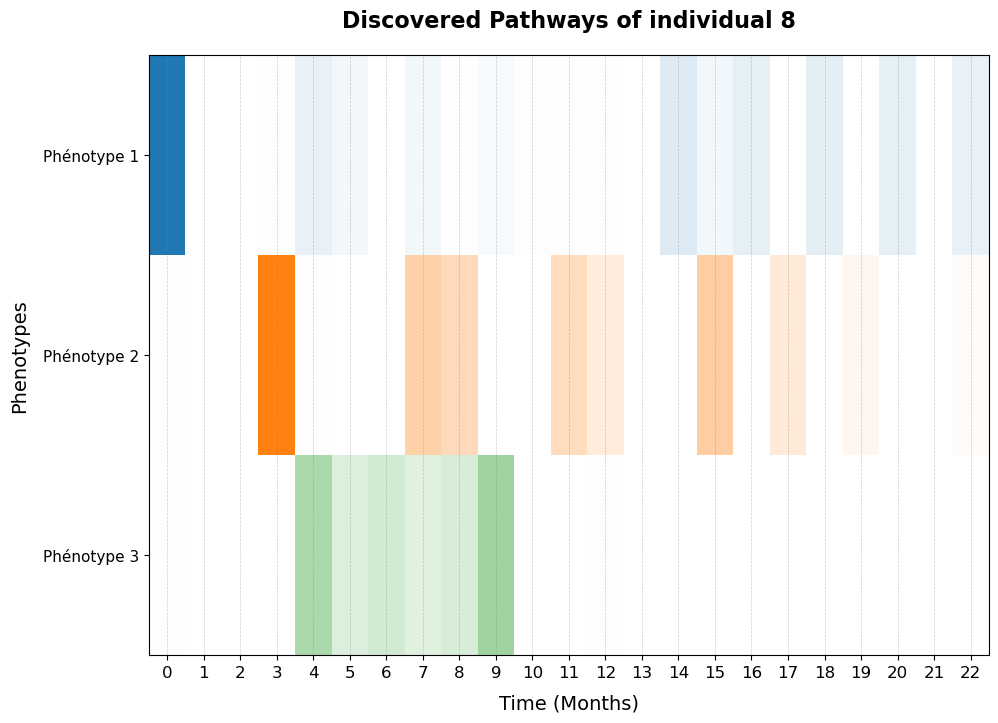

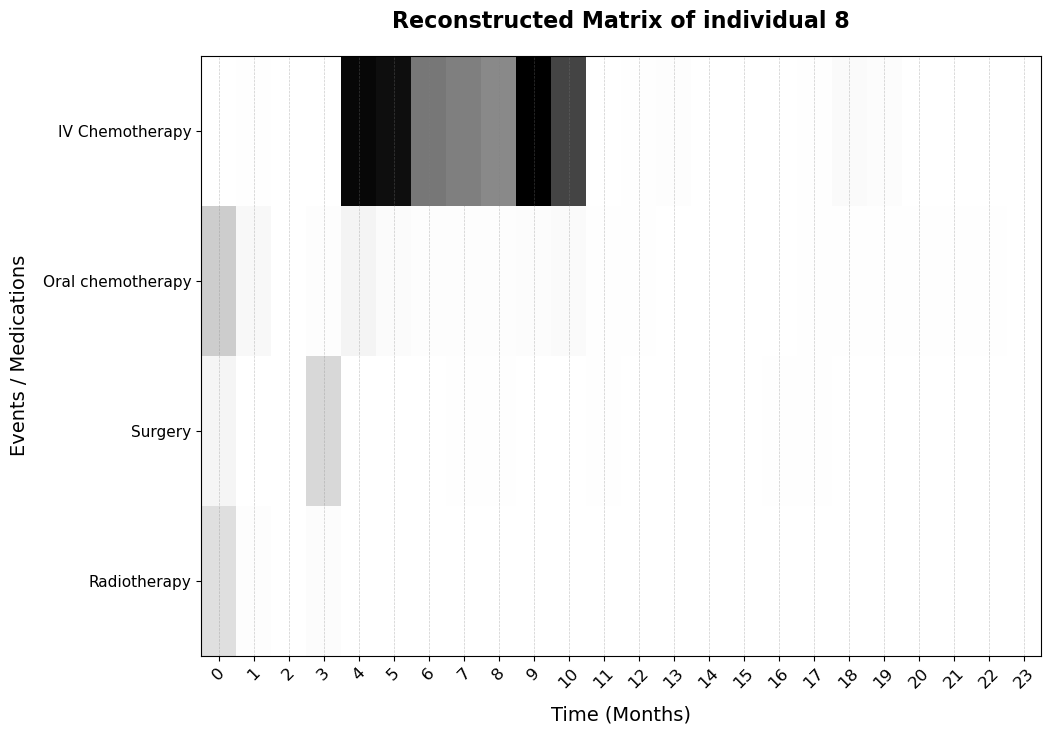

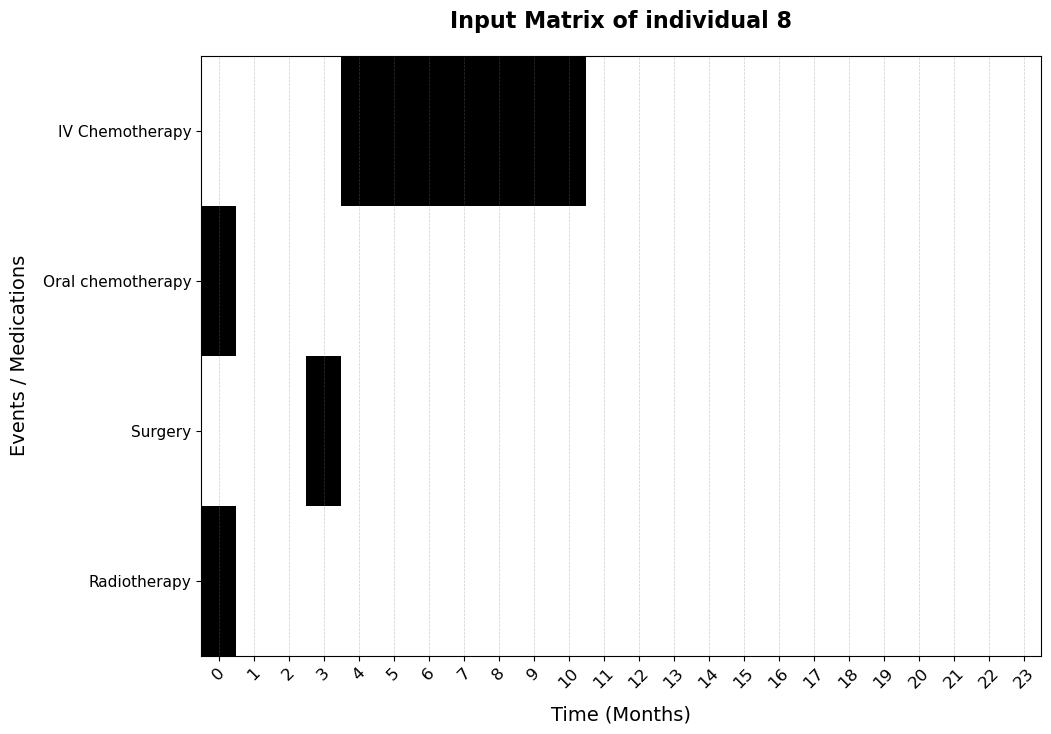

In [23]:
best = results_df.iloc[5]

print("=== Meilleure configuration ===")
print(f"rank      : {best['rank']}")
print(f"twl       : {best['time_window_length']}")
print(f"alpha_rel : {best['alpha_rel']:.2e}")
print(f"gamma_rel : {best['gamma_rel']:.2e}")
print(f"alpha     : {best['alpha']:.2e}")
print(f"gamma     : {best['gamma']:.2e}")
print(f"FIT_X     : {best['best_fit_metric']:.4f}")
print(f"div_cos  : {best['div_cos']:.4f}")

plot_training_history(best)

best['tca_trial'].analyzer.get_decomposition_results(
    labels=name_events, id=8, time_unit="Months"
)

## 5. Clustering Based on Phenotype Intensities

The ultimate goal of the SWoTTeD decomposition is to group patients into clinically interpretable clusters. Once the phenotypes have been learned, each patient $k$ is summarized by an intensity vector of size $R$, obtained by summing the activations of their matrix $W^{(k)}$ over the entire follow-up period and then normalizing the result. Clustering is applied to this compact representation.

In [24]:
from sklearn.preprocessing import MinMaxScaler

best_tca = best['tca_trial']

ph_intensity = best_tca.analyzer.to_phenotype_intensity(scaler=MinMaxScaler(feature_range=(0, 1)))
print("Shape intensites:", ph_intensity.shape)
ph_intensity.head()

Shape intensites: (1336, 4)


,Phenotype_1,Phenotype_2,Phenotype_3,ID_PATIENT
0,0.016466,0.242689,0.298454,1
1,0.023609,0.232969,0.290037,2
2,0.447731,0.278460,0.772237,3
3,0.018523,0.245252,0.447909,4
4,0.032487,0.235850,0.297319,5


INFO:root:Calculating distance matrix using metric: euclidean...
INFO:root:Time taken for computation: 0.01 seconds
INFO:root:Computing the linkage matrix using method: ward...
c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src\trajectoryclusteringanalysis\unidimensional\clustering.py:238: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(condensed_distance_matrix, method=method, optimal_ordering=optimal_ordering)
INFO:root:Linkage matrix computed successfully


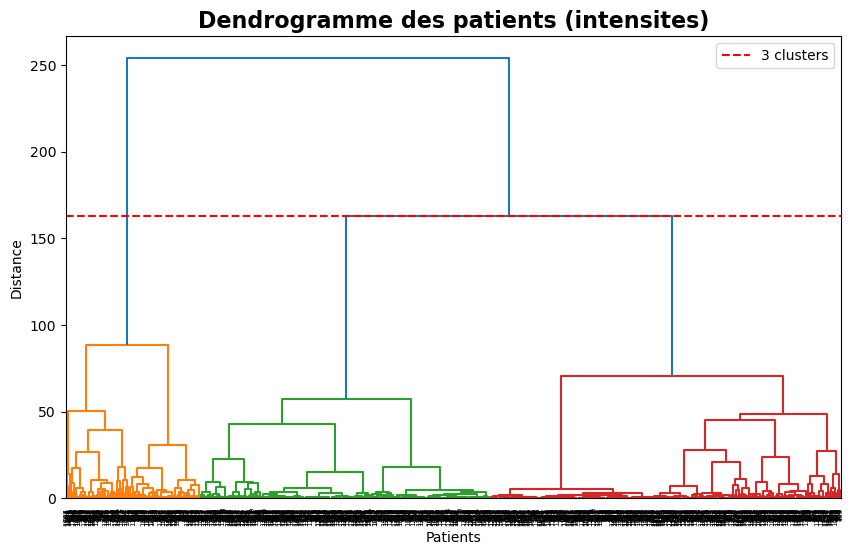

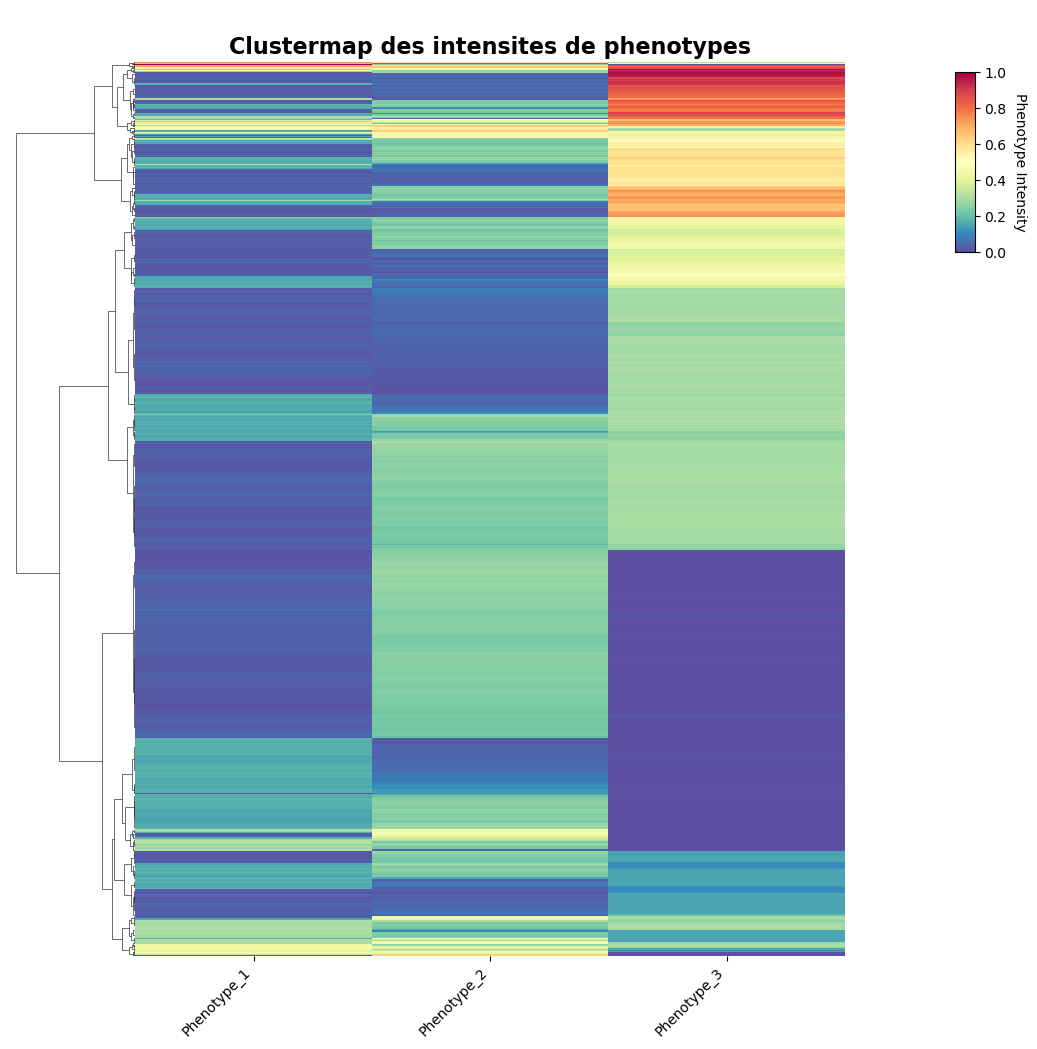

In [ ]:
distance_matrix = best_tca.compute_distance_matrix(data=ph_intensity, metric='euclidean')
linkage_matrix = best_tca.hierarchical_clustering(distance_matrix)

best_tca.plot_dendrogram(linkage_matrix, title='Dendrogramme des patients (intensites)', n_clusters=3)
best_tca.plot_clustermap(ph_intensity, linkage_matrix, title='Clustermap des intensites de phenotypes')

Effectifs par cluster:
1    232
2    498
3    606
Name: count, dtype: int64


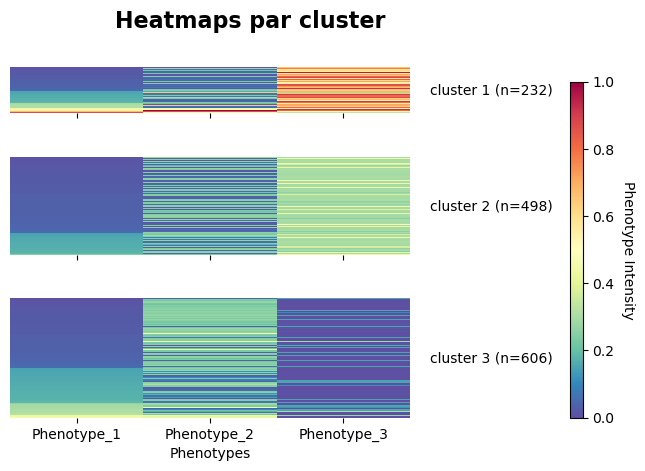

In [34]:
clusters = best_tca.assign_clusters(linkage_matrix, num_clusters=3)
print("Effectifs par cluster:")
print(pd.Series(clusters).value_counts().sort_index())

best_tca.plot_cluster_heatmaps(ph_intensity, clusters, sorted=True, title='Heatmaps par cluster')